In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from multicam_bolshoi.mah import get_mah
mah_data = get_mah('../../data/processed/bolshoi_m12', cutoff_missing=0.05, cutoff_particle=0.05)

# extract mah of all haloes 
ma = mah_data['ma_peak']
ma.shape # the first dimension is the number of haloes, the second is the number of snapshots.

scales = mah_data['scales']
scales.shape


cat = mah_data['cat'] # astropy table with present-day halo properties
cvir = cat['cvir']
xoff = cat['x0']
t_over_u = cat['t/|u|']
spin = cat['spin_bullock']
c_to_a = cat['c_to_a']

cvir.shape, spin.shape # 1 dimensional quantities, one per halo


((10000,), (10000,))

In [16]:
from multicam.multicam import MultiCAM
from multicam_bolshoi.old_multicam import MultiCAM as MultiCAM2
from multicam_bolshoi.old_old_multicam import MultiCAM as MultiCAM3

# Compare models (no split)

In [4]:
n_features = ma.shape[1] # number of features is the number of scales
n_targets = 1 # number of targets is 1, the present-day halo property
model1 = MultiCAM(n_features, n_targets)
model2 = MultiCAM2(n_features, n_targets)
model3 = MultiCAM3(n_features, n_targets)

In [6]:
model1.fit(ma, cvir.reshape(-1, 1))
model2.fit(ma, cvir.reshape(-1, 1))
model3.fit(ma, cvir.reshape(-1,1))

AssertionError: 

In [7]:
cvir_pred1 = model1.predict(ma)
cvir_pred2 = model2.predict(ma)
cvir_pred3 = model3.predict(ma)

In [9]:
spearmanr(cvir_pred1, cvir), spearmanr(cvir_pred2, cvir), spearmanr(cvir_pred3, cvir)

(SignificanceResult(statistic=np.float64(0.7633404593680908), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.8078217749156709), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.801347752034326), pvalue=np.float64(0.0)))

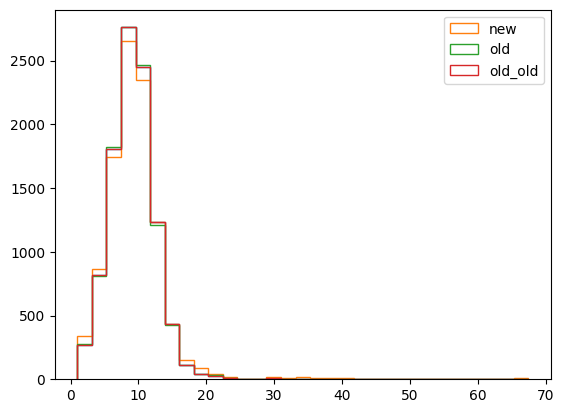

In [12]:
_, bins, _ = plt.hist(cvir, bins=31, histtype='step')
plt.hist(cvir_pred1, bins=bins, histtype='step', label='new')
plt.hist(cvir_pred2, bins=bins, histtype='step', label='old');
plt.hist(cvir_pred3, bins=bins, histtype='step', label='old_old');
plt.legend()

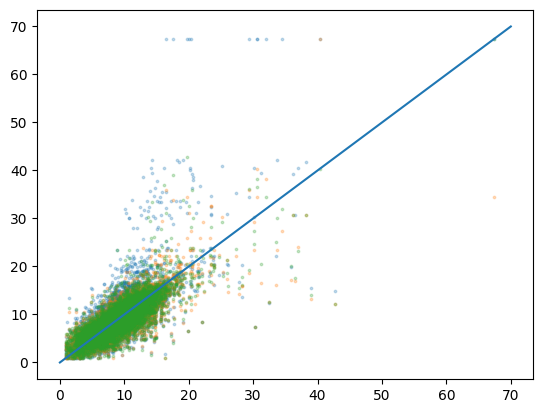

In [13]:
plt.scatter(cvir, cvir_pred1, s=3, alpha=0.25)
plt.scatter(cvir, cvir_pred2, s=3, alpha=0.25)
plt.scatter(cvir, cvir_pred3, s=3, alpha=0.25)
plt.plot([0, 70], [0, 70])

In [ ]:
# from multicam.train import _get_tt_indices

# n_haloes = len(cat)
# train_idx, test_idx = _get_tt_indices(n_haloes, test_ratio=0.25)

In [ ]:
# ma_train = ma[train_idx]
# ma_test = ma[test_idx]
# cvir_train = cvir[train_idx]
# cvir_test = cvir[test_idx]

# ma_train.shape

# Test basic functions

In [68]:
from multicam.qt import qt_gauss_base, qt_gauss, qt_inverse_gauss_base

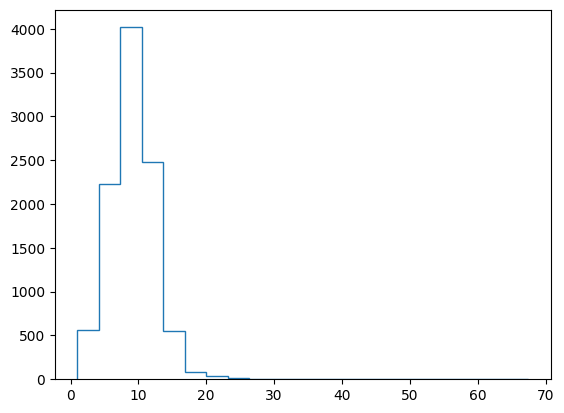

In [21]:
plt.hist(cvir, bins=21, histtype='step');

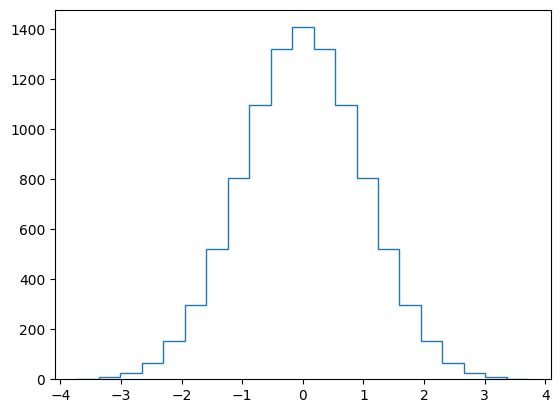

In [22]:
plt.hist(qt_gauss(cvir), bins=21, histtype='step');

In [45]:
from multicam.train import _get_tt_indices

n_haloes = len(cat)
train_idx, test_idx = _get_tt_indices(n_haloes, test_ratio=0.25)

In [46]:
cvir_train = cvir[train_idx]
cvir_test = cvir[test_idx]
cvir_train.shape, cvir_test.shape

((7500,), (2500,))

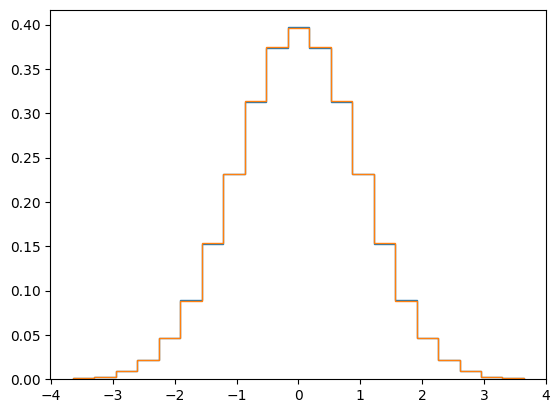

In [47]:
_, bins, _ = plt.hist(qt_gauss(cvir_train), bins=21, histtype='step', density=True);
plt.hist(qt_gauss(cvir_test), bins=bins, histtype='step', density=True);

In [48]:
cvir_gauss = qt_gauss_base(cvir_test.reshape(-1, 1), cvir_train.reshape(-1, 1))
cvir_gauss.shape

(2500, 1)

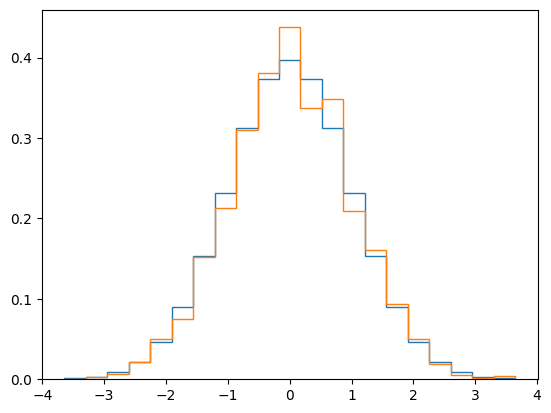

In [57]:
_, bins, _ = plt.hist(qt_gauss(cvir_train), bins=21, density=True, histtype='step');
plt.hist(cvir_gauss[:, 0], bins=bins, density=True, histtype='step');

In [52]:
from sklearn.preprocessing import QuantileTransformer


def _gauss_transform(x: np.ndarray):
    """Transform x to be (marginally) gaussian."""
    assert x.ndim == 2
    qt = QuantileTransformer(n_quantiles=len(x), output_distribution="normal")
    qt.fit(x)
    return qt.transform(x), qt

In [60]:
cvir_train_gauss, qt = _gauss_transform(cvir_train.reshape(-1,1))
cvir_gauss2 = qt.transform(cvir_test.reshape(-1,1))

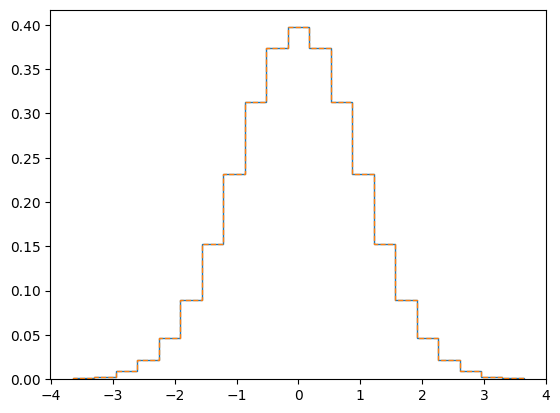

In [63]:
_, bins, _ = plt.hist(qt_gauss(cvir_train), bins=21, density=True, histtype='step', ls='-');
plt.hist(cvir_train_gauss, bins=bins, density=True, histtype='step', ls='--');

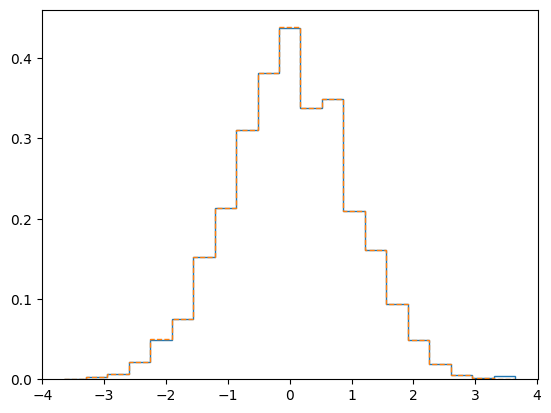

In [65]:
plt.hist(cvir_gauss[:, 0], bins=bins, density=True, histtype='step');
plt.hist(cvir_gauss2[:, 0], bins=bins, density=True, histtype='step', ls='--');

In [69]:
## Try inverse

cvir1 = qt_inverse_gauss_base(cvir_gauss.reshape(-1, 1), cvir_train.reshape(-1, 1))
cvir2 = qt.inverse_transform(cvir_gauss2.reshape(-1,1))

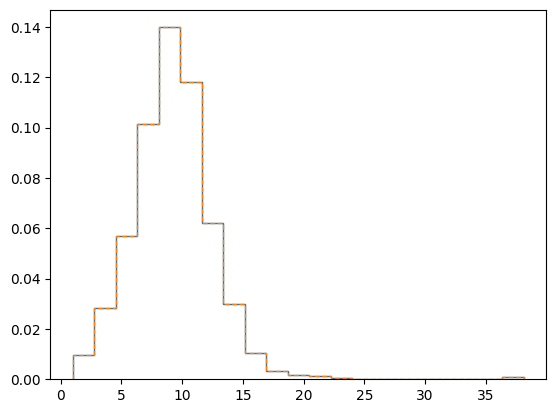

In [70]:
_, bins, _ = plt.hist(cvir1[:, 0], bins=21, density=True, histtype='step');
plt.hist(cvir2[:, 0], bins=bins, density=True, histtype='step', ls='--');

## Apples to apples comparison of each output (try 1D)

In [83]:
from multicam.qt import qt_gauss_base, qt_gauss, qt_inverse_gauss_base
from sklearn import linear_model


def multicam_one(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss = qt_gauss(x_train, axis=0)
    yt_gauss = qt_gauss(y_train, axis=0)

    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qt_gauss_base(x, x_train)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    y_gauss = qt_gauss_base(y_not_gauss, y_pred_train)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qt_inverse_gauss_base(y_gauss, y_train) 
    return y_pred, y_gauss, y_not_gauss, x_gauss



def _gauss_transform(x: np.ndarray):
    """Transform x to be (marginally) gaussian."""
    assert x.ndim == 2
    qt = QuantileTransformer(n_quantiles=len(x), output_distribution="normal", subsample=None)
    qt.fit(x)
    return qt.transform(x), qt


def multicam_two(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss, qtx = _gauss_transform(x_train)
    yt_gauss, qty = _gauss_transform(y_train)
    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qtx.transform(x)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    _, qtp = _gauss_transform(y_pred_train)
    y_gauss = qtp.transform(y_not_gauss)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qty.inverse_transform(y_gauss)
    return y_pred, y_gauss, y_not_gauss, x_gauss



In [75]:
from multicam.train import _get_tt_indices

n_haloes = len(cat)
train_idx, test_idx = _get_tt_indices(n_haloes, test_ratio=0.25)

In [94]:
a2 = ma[:, 41, None]

ma_train = ma[train_idx]
ma_test = ma[test_idx]
a2_train = a2[train_idx]
cvir_train = cvir[train_idx].reshape(-1, 1)
a2_test = a2[test_idx]
cvir_test = cvir[test_idx].reshape(-1, 1)
a2_train.shape, cvir_train.shape

((7500, 1), (7500, 1))

In [95]:
yp1, yg1, yng1, xg1 = multicam_one(ma_test, ma_train, cvir_train)
yp2, yg2, yng2, xg2 = multicam_two(ma_test, ma_train, cvir_train)

In [125]:
xg2[:, 130].max()

np.float64(5.19933758270342)

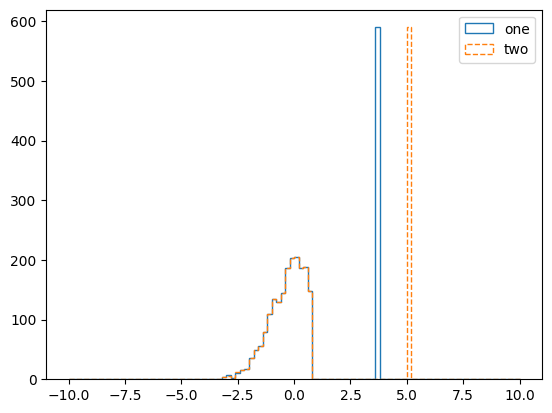

In [126]:
idx = 130
bins = np.linspace(-10, 10, 101)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='one')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='two');
plt.legend()

In [ ]:
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='one')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='two');
plt.legend()

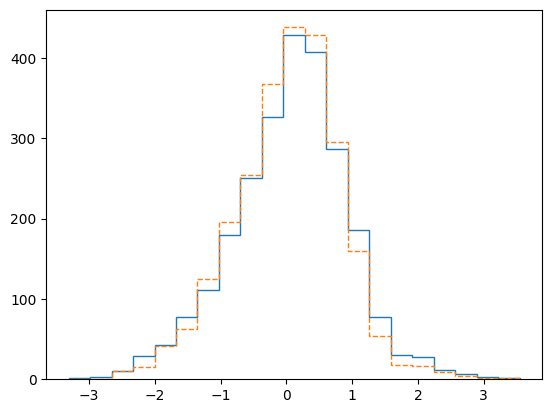

In [98]:
_, bins, _ = plt.hist(yng1, bins=21, histtype='step')
plt.hist(yng2, bins=bins, histtype='step', ls='--');

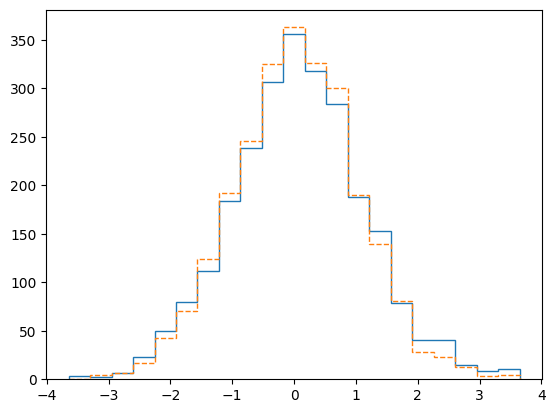

In [99]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step')
plt.hist(yg2, bins=bins, histtype='step', ls='--');

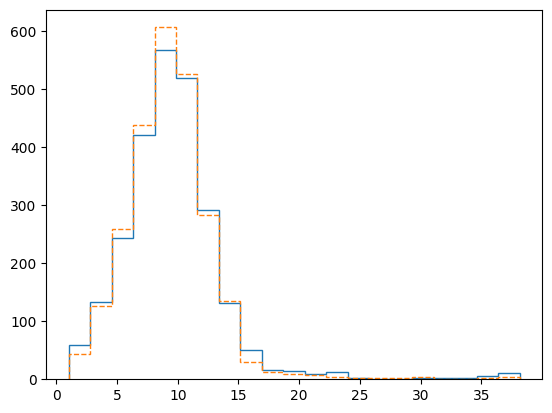

In [100]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');

In [101]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.718743493934944), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7758868864028721), pvalue=np.float64(0.0)))